In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import matplotlib.pyplot as plt
from scipy import stats

In [22]:
methods = ['NNLS', 'L2reg']
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets
eval_ds_names = [ds if gl.sessions[i] == 'all' else ds + gl.sessions[i].split('-')[1] for i, ds in enumerate(gl.datasets)]
df_all = pd.DataFrame()
for i, (ds_code, ds_eval) in enumerate(zip(train_ds_list, eval_ds_names)):
    df = rm.comb_eval(models=[ds_code+"-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_hipp = rm.comb_eval(models=[ds_code+"+hipp-global-Cavg"],methods=methods,eval_data=[ds_eval],cerebellum='MNISymC3')
    df_all = pd.concat([df_all, df, df_hipp], ignore_index=True)
df_all['logalpha'] = df_all['logalpha'].fillna(-4)
df_all.model = 'Global'

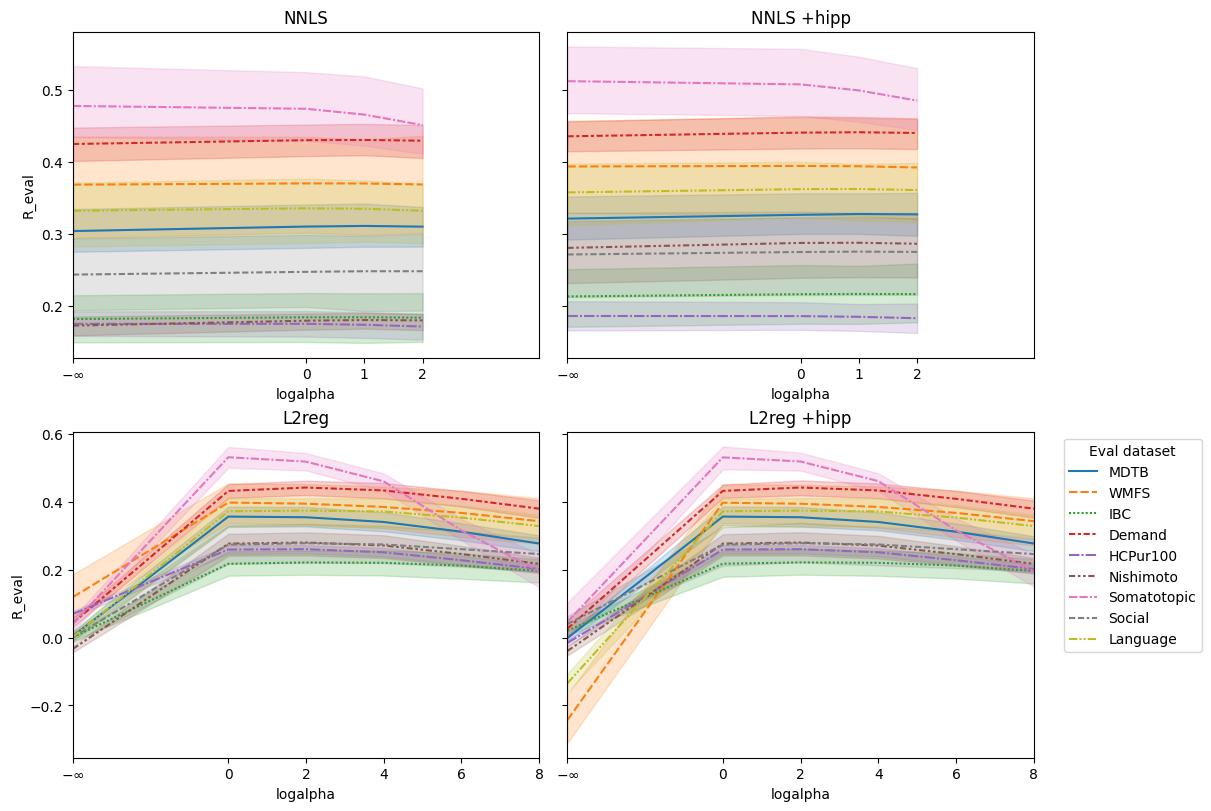

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row', constrained_layout=True)
for i, method in enumerate(methods):
    sns.lineplot(data=df_all[(df_all['method']==method) & (df_all['hippocampus'].isna())],
                 y='R_eval', x='logalpha',
                 hue='eval_dataset', style='eval_dataset',
                 hue_order=eval_ds_list, style_order=eval_ds_list, ax=axes[i,0])
    axes[i,0].set_title(method)
        
    sns.lineplot(data=df_all[(df_all['method']==method) & (~df_all['hippocampus'].isna())],
                 y='R_eval', x='logalpha',
                 hue='eval_dataset', style='eval_dataset',
                 hue_order=eval_ds_list, style_order=eval_ds_list, ax=axes[i,1])
    axes[i,1].set_title(f"{method} +hipp")

    axes[i,0].legend_.remove()
    axes[i,1].legend_.remove()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Eval dataset');

for i in range(2):
    xticks = df_all[df_all['method']==methods[i]]['logalpha'].unique()
    xticklabels = [r"$-\infty$" if np.isclose(t, -4) else str(int(t)) for t in xticks]
    axes[i,0].set_xticks(xticks)
    axes[i,1].set_xticks(xticks)
    axes[i,0].set_xticklabels(xticklabels)
    axes[i,1].set_xticklabels(xticklabels)
axes[0,0].set_xlim([-4, 4]);
axes[0,1].set_xlim([-4, 4]);
axes[1,0].set_xlim([-4, 8]);
axes[1,1].set_xlim([-4, 8]);

In [24]:
for method in methods:
    for hipp in [False, True]:
        if hipp:
            print(f'\nMethod: {method} +hipp')
            df_method = df_all[(df_all['method'] == method) & (~df_all['hippocampus'].isna())]
        else:
            print(f'\nMethod: {method}')
            df_method = df_all[(df_all['method'] == method) & (df_all['hippocampus'].isna())]
        A = pd.pivot_table(df_method, index=['model'], columns=['logalpha'], values=['R_eval'], aggfunc='mean')#.reindex(train_ds_list)
        display(A)
        B = np.nan_to_num(A.values)
        ind = B.argmax(axis=1)
        log_a = np.array(A.columns.get_level_values(1)[ind])
        bestla = pd.DataFrame(log_a, index=A.index, columns=['best_logalpha'])
        display(bestla)
        df_all.loc[df_method.index, 'isbest'] = df_method['logalpha'].values == bestla.loc[df_method['model']].values.flatten()
df_best = df_all[df_all['isbest']]


Method: NNLS


R_eval                             
logalpha     -4.0      0.0       1.0       2.0
model                                         
Global    0.29041  0.29331  0.292853  0.290881

,best_logalpha
model,
Global,0.0



Method: NNLS +hipp


R_eval                              
logalpha      -4.0       0.0       1.0       2.0
model                                           
Global    0.311817  0.314506  0.314212  0.312474

...

R_eval                                                            
logalpha     -4.0       0.0       2.0       4.0       6.0       8.0       10.0
model                                                                         
Global    0.037962  0.336939  0.339128  0.329091  0.302748  0.273275  0.263966

,best_logalpha
model,
Global,2.0



Method: L2reg +hipp


R_eval                                                         
logalpha     -4.0     0.0       2.0       4.0      6.0       8.0       10.0
model                                                                      
Global   -0.024799  0.3369  0.339154  0.329142  0.30277  0.273316  0.264012

,best_logalpha
model,
Global,2.0


/localscratch/tmp/ipykernel_554205/2420226950.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best['hippocampus'] = df_best['hippocampus'].fillna('None')


<Axes: xlabel='method', ylabel='R_eval'>

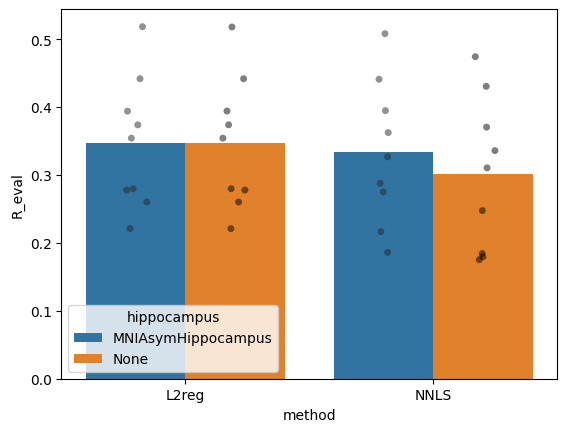

In [25]:
att_to_plot = 'R_eval'
df_best['hippocampus'] = df_best['hippocampus'].fillna('None')
df_summary = (df_best.groupby(['eval_dataset', 'method', 'hippocampus'], as_index=False)[att_to_plot].mean())

sns.barplot(data=df_summary, x='method', y=att_to_plot, hue='hippocampus', errorbar=None)
sns.stripplot(data=df_summary, x='method', y=att_to_plot, hue='hippocampus',
              dodge=True, jitter=True, alpha=0.5, palette='dark:black', legend=False)
# plt.ylim([0, 1])

<Axes: xlabel='eval_dataset', ylabel='R_eval'>

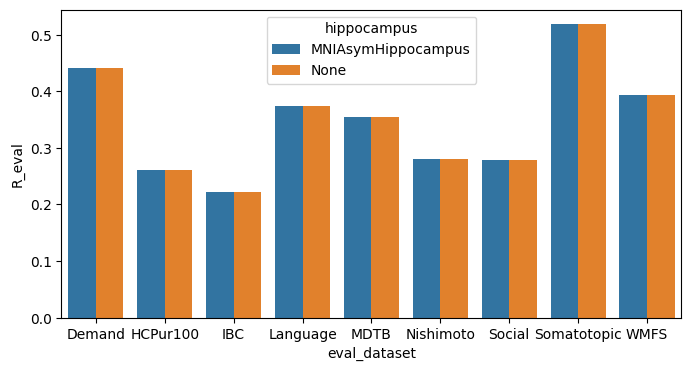

In [26]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_summary[df_summary['method']=='L2reg'], x='eval_dataset', y=att_to_plot, hue='hippocampus')
# plt.ylim([0, 1])

In [27]:
df_nc = (df_best.groupby(['eval_dataset', 'hippocampus'], as_index=False)['group_noiseceiling'].mean())
print(df_nc)

   eval_dataset         hippocampus  group_noiseceiling
0        Demand  MNIAsymHippocampus            0.484532
1        Demand                None            0.484714
2      HCPur100  MNIAsymHippocampus            0.280275
3      HCPur100                None            0.281243
4           IBC  MNIAsymHippocampus            0.275851
5           IBC                None            0.278629
6      Language  MNIAsymHippocampus            0.411293
7      Language                None            0.411703
8          MDTB  MNIAsymHippocampus            0.404713
9          MDTB                None            0.405065
10    Nishimoto  MNIAsymHippocampus            0.326754
11    Nishimoto                None            0.331539
12       Social  MNIAsymHippocampus            0.314436
13       Social                None            0.315426
14  Somatotopic  MNIAsymHippocampus            0.685370
15  Somatotopic                None            0.686772
16         WMFS  MNIAsymHippocampus            0